🧠 1. Atlas ve fMRI verisi yükleniyor...
[fetch_atlas_schaefer_2018] Dataset found in /home/jovyan/nilearn_data/schaefer_2018
[fetch_development_fmri] Dataset found in /home/jovyan/nilearn_data/development_fmri
[fetch_development_fmri] Dataset found in /home/jovyan/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Dataset found in /home/jovyan/nilearn_data/development_fmri/development_fmri
⚙️ 2. Beyin bölgelerinden sinyaller ayrıştırılıyor...


/tmp/ipykernel_163/1079393743.py:27: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(fmri_filename)


🔗 3. Korelasyon matrisi hesaplanıyor...


/tmp/ipykernel_163/1079393743.py:32: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  correlation_matrix = correlation_measure.fit_transform([time_series])[0]


   -> 'brain_matrix.png' kaydedildi.
📐 4. Graph Theory metrikleri hesaplanıyor...

🧠 BEYİN ANALİZ RAPORU
Global Verimlilik (Network Efficiency): 0.6278
🏆 EN ÖNEMLİ 5 BÖLGE (HUBS):
 - Bölge #68 (0.7374): 7Networks_RH_DorsAttn_Post_2
 - Bölge #34 (0.6465): 7Networks_LH_Cont_Par_1
 - Bölge #41 (0.6465): 7Networks_LH_Default_Par_2
 - Bölge #7 (0.6263): 7Networks_LH_Vis_7
 - Bölge #72 (0.6162): 7Networks_RH_DorsAttn_PrCv_1

🎨 5. Cam Beyin çiziliyor ve kaydediliyor...
   -> 'brain_connectome.png' kaydedildi.

✅ ANALİZ TAMAMLANDI!


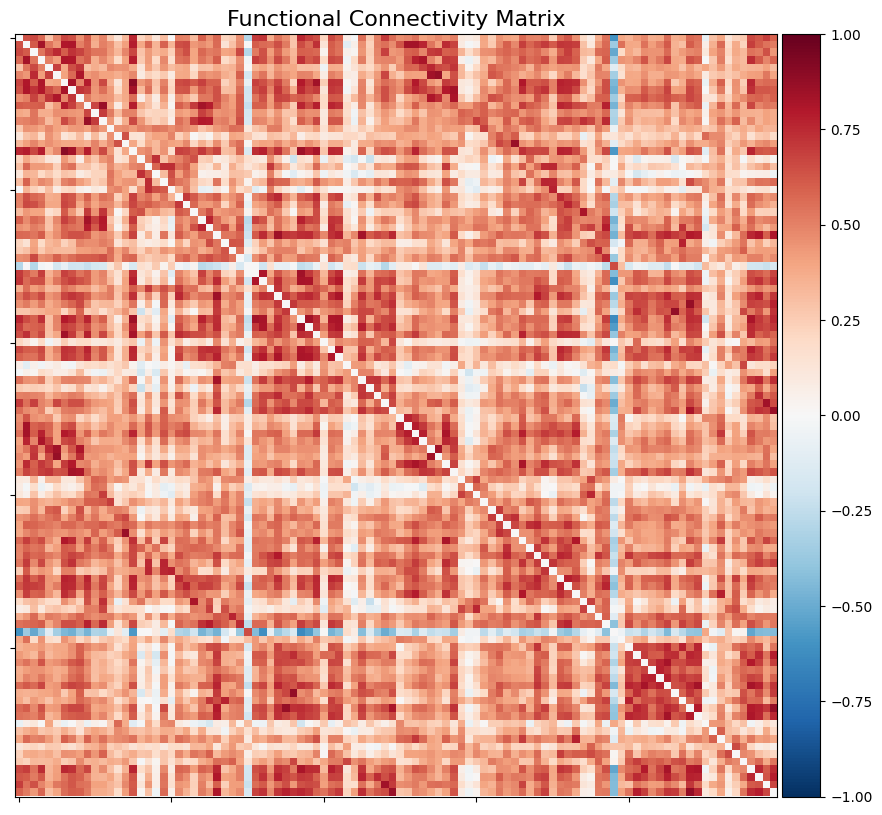

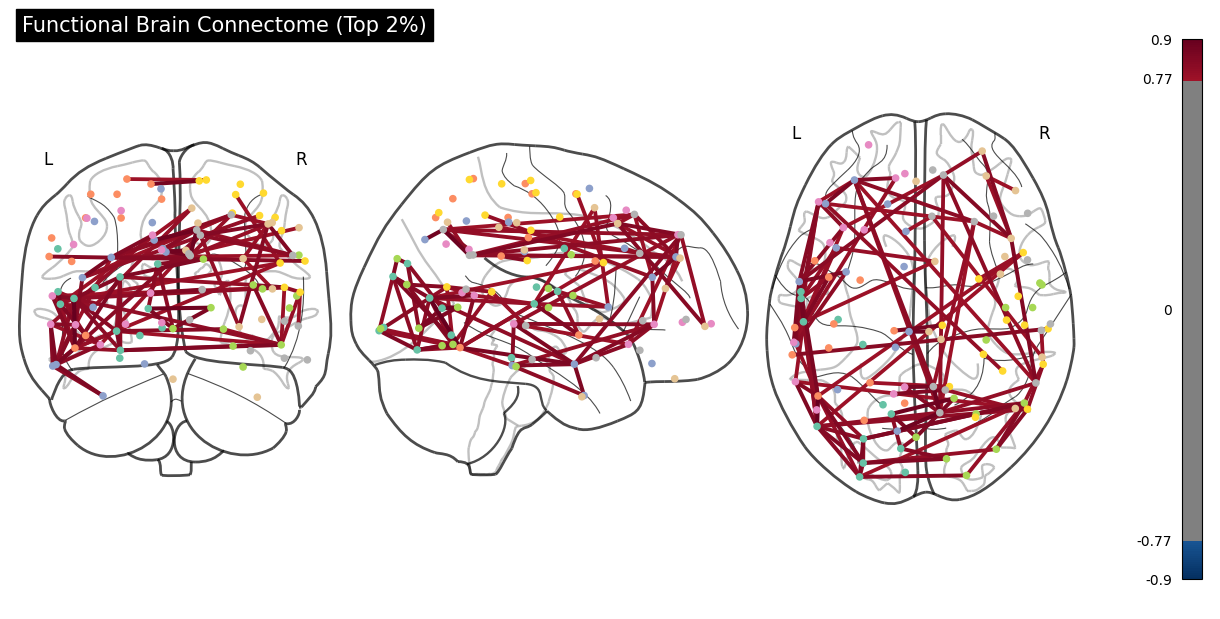

In [26]:
# ==========================================
# PROJE: Functional Brain Connectivity & Graph Theory Analysis
# YAZAR: [Adın Soyadın]
# AÇIKLAMA: Schaefer Atlası ve fMRI verisi kullanılarak Beyin Bağlantısallık Analizi
# ==========================================

import numpy as np
import pandas as pd
import networkx as nx
from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
import matplotlib.pyplot as plt

# 1. VERİ VE ATLAS YÜKLEME
print("🧠 1. Atlas ve fMRI verisi yükleniyor...")
dataset = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_filename = dataset.maps
labels = dataset.labels

data = datasets.fetch_development_fmri(n_subjects=1)
fmri_filename = data.func[0]

# 2. SİNYAL İŞLEME (Time Series Extraction)
print("⚙️ 2. Beyin bölgelerinden sinyaller ayrıştırılıyor...")
masker = NiftiLabelsMasker(labels_img=atlas_filename, standardize=True)
time_series = masker.fit_transform(fmri_filename)

# 3. BAĞLANTISALLIK MATRİSİ (Connectivity Matrix)
print("🔗 3. Korelasyon matrisi hesaplanıyor...")
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([time_series])[0]
np.fill_diagonal(correlation_matrix, 0)

# GÖRSEL 1: Matris Isı Haritası (Kaydet)
plt.figure(figsize=(10, 8))
plotting.plot_matrix(correlation_matrix, figure=plt.gcf(), vmax=1.0, vmin=-1.0, colorbar=True, title="Functional Connectivity Matrix")
plt.savefig("brain_matrix.png", dpi=300) # Resim olarak kaydettik
print("   -> 'brain_matrix.png' kaydedildi.")

# 4. GRAPH THEORY ANALİZİ (Ağ Analizi)
print("📐 4. Graph Theory metrikleri hesaplanıyor...")
threshold = 0.5
adj_matrix = correlation_matrix.copy()
adj_matrix[adj_matrix < threshold] = 0
G = nx.from_numpy_array(adj_matrix)

# Metrikler
global_eff = nx.global_efficiency(G)
degree_centrality = nx.degree_centrality(G)
top_hubs = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

# 5. SONUÇLARI RAPORLA
print("\n" + "="*40)
print(f"🧠 BEYİN ANALİZ RAPORU")
print(f"Global Verimlilik (Network Efficiency): {global_eff:.4f}")
print("="*40)
print("🏆 EN ÖNEMLİ 5 BÖLGE (HUBS):")

hub_report = []
for node_id, score in top_hubs:
    if node_id < len(labels):
        region_name = labels[node_id].decode() if hasattr(labels[node_id], 'decode') else labels[node_id]
        print(f" - Bölge #{node_id} ({score:.4f}): {region_name}")
        hub_report.append(f"{region_name} ({score:.4f})")

# GÖRSEL 2: Cam Beyin (Glass Brain) - Kaydet
print("\n🎨 5. Cam Beyin çiziliyor ve kaydediliyor...")
coords = plotting.find_parcellation_cut_coords(labels_img=atlas_filename)
fig = plt.figure(figsize=(12, 6))
plotting.plot_connectome(correlation_matrix, coords, edge_threshold="98%", 
                         title="Functional Brain Connectome (Top 2%)", 
                         node_size=20, colorbar=True, figure=fig)
plt.savefig("brain_connectome.png", dpi=300) # Resim olarak kaydettik
print("   -> 'brain_connectome.png' kaydedildi.")
print("\n✅ ANALİZ TAMAMLANDI!")